# Graph-JEPA: `n local + m stratified random`

Сравнение downstream-метрик при фиксированных четырёх target-масках. По оси X — число stratified-random targets; число local targets равно `4 - m`. Baseline `2L+2R` включён в общую шкалу.

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# При запуске локально укажи скачанный CSV; на сервере оставь абсолютный путь.
REPORT_CSV = Path('/workspace-SR004.nfs2/konovalov/tactile/experiments/significance/jepa_local_random_mix/significance_results.csv')
if not REPORT_CSV.exists():
    REPORT_CSV = Path('../experiments/significance/jepa_local_random_mix/significance_results.csv')

CUMULATIVE_CSV = Path('/workspace-SR004.nfs2/konovalov/tactile/experiments/significance/graph_jepa_cumulative/significance_results.csv')
if not CUMULATIVE_CSV.exists():
    CUMULATIVE_CSV = Path('../experiments/significance/graph_jepa_cumulative/significance_results.csv')

BASELINE_CSV = Path('/workspace-SR004.nfs2/konovalov/tactile/experiments/significance/purple_only_signal_with_jepa/significance_results.csv')
if not BASELINE_CSV.exists():
    BASELINE_CSV = Path('../experiments/significance/purple_only_signal_with_jepa/significance_results.csv')

df = pd.concat([pd.read_csv(REPORT_CSV), pd.read_csv(CUMULATIVE_CSV), pd.read_csv(BASELINE_CSV)], ignore_index=True)

METHODS = {
    'graph_physical_dijkstra_1c4t_c50_90_t10_18': (0, '4 local'),
    'graph_physical_dijkstra_1c4t_3local1stratifiedrandom_c50_90_t10_18': (1, '3 local + 1 random'),
    'graph_physical_dijkstra_1c4t_2local2stratifiedrandom_c50_90_t10_18': (2, '2 local + 2 random'),
    'graph_physical_dijkstra_1c4t_1local3stratifiedrandom_c50_90_t10_18': (3, '1 local + 3 random'),
    'graph_physical_dijkstra_1c4t_4stratifiedrandom_c50_90_t10_18': (4, '4 random'),
}
df['experiment_id'] = df['experiment_id'].replace({
    'graph_jepa_1c4t_c50_90_t10_18': 'graph_physical_dijkstra_1c4t_c50_90_t10_18',
    'graph_jepa_1c4t_2local2stratifiedrandom_c50_90_t10_18': 'graph_physical_dijkstra_1c4t_2local2stratifiedrandom_c50_90_t10_18',
})
df = df[df['experiment_id'].isin(METHODS)].copy()
df = df.drop_duplicates(subset=['task', 'metric', 'experiment_id'], keep='first')
df['random_targets'] = df['experiment_id'].map(lambda x: METHODS[x][0])
df['method_label'] = df['experiment_id'].map(lambda x: METHODS[x][1])
df = df.sort_values(['random_targets', 'is_baseline'])

print(f'Loaded {len(df)} metric rows from {REPORT_CSV}')
display(df[['task', 'metric', 'random_targets', 'method_label', 'estimate', 'bootstrap_se']].head())

Loaded 55 metric rows from /workspace-SR004.nfs2/konovalov/tactile/experiments/significance/jepa_local_random_mix/significance_results.csv


,task,metric,random_targets,method_label,estimate,bootstrap_se
4,force,rmse,0,4 local,0.151093,0.009170
5,force,rmse_x,0,4 local,0.037587,0.003053
6,force,rmse_y,0,4 local,0.042018,0.003383
7,force,rmse_z,0,4 local,0.255556,0.015942
204,pose,rmse_x,0,4 local,0.010290,0.000809


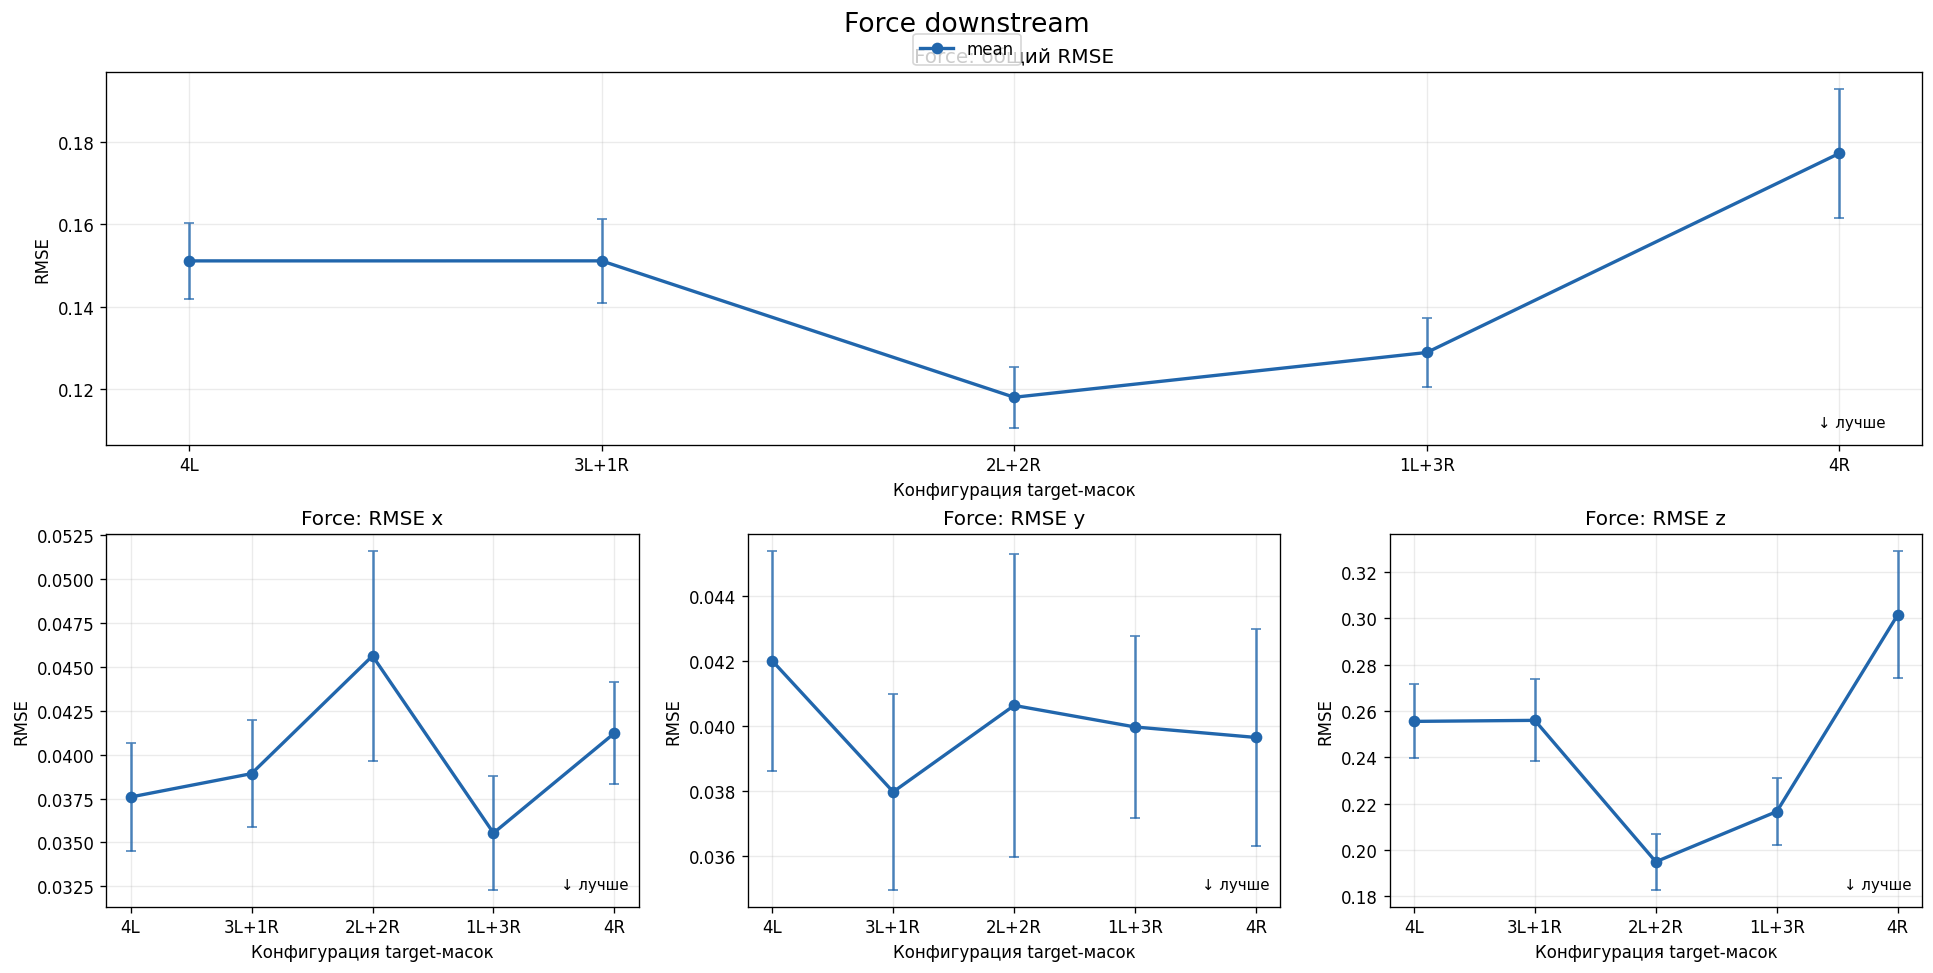

In [7]:
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.25})
COLORS = ['#2166ac', '#67a9cf', '#fdae61', '#d6604d', '#b2182b']

def series(task, metric):
    part = df[(df.task == task) & (df.metric == metric)].sort_values('random_targets')
    return part

def draw(ax, task, metric, title, ylabel, lower_is_better=False):
    part = series(task, metric).sort_values('random_targets')
    x = part['random_targets'].to_numpy()
    y = part['estimate'].to_numpy()
    se = part['bootstrap_se'].to_numpy()
    ax.plot(x, y, marker='o', linewidth=2, color='#2166ac', label='mean')
    ax.errorbar(x, y, yerr=se, fmt='none', ecolor='#2166ac', capsize=3, alpha=0.8)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(5))
    ax.set_xticklabels(['4L', '3L+1R', '2L+2R', '1L+3R', '4R'])
    ax.set_xlabel('Конфигурация target-масок')
    if lower_is_better:
        ax.text(0.98, 0.04, '↓ лучше', transform=ax.transAxes, ha='right', va='bottom', fontsize=9)
    else:
        ax.text(0.98, 0.04, '↑ лучше', transform=ax.transAxes, ha='right', va='bottom', fontsize=9)

# 1. Force: общий RMSE и RMSE по координатам.
fig = plt.figure(figsize=(16, 8), constrained_layout=True)
gs = fig.add_gridspec(2, 3)
ax = fig.add_subplot(gs[0, :])
draw(ax, 'force', 'rmse', 'Force: общий RMSE', 'RMSE', lower_is_better=True)
for j, coord in enumerate(['x', 'y', 'z']):
    draw(fig.add_subplot(gs[1, j]), 'force', f'rmse_{coord}', f'Force: RMSE {coord}', 'RMSE', lower_is_better=True)
fig.suptitle('Force downstream', fontsize=16)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 0.98))
plt.show()

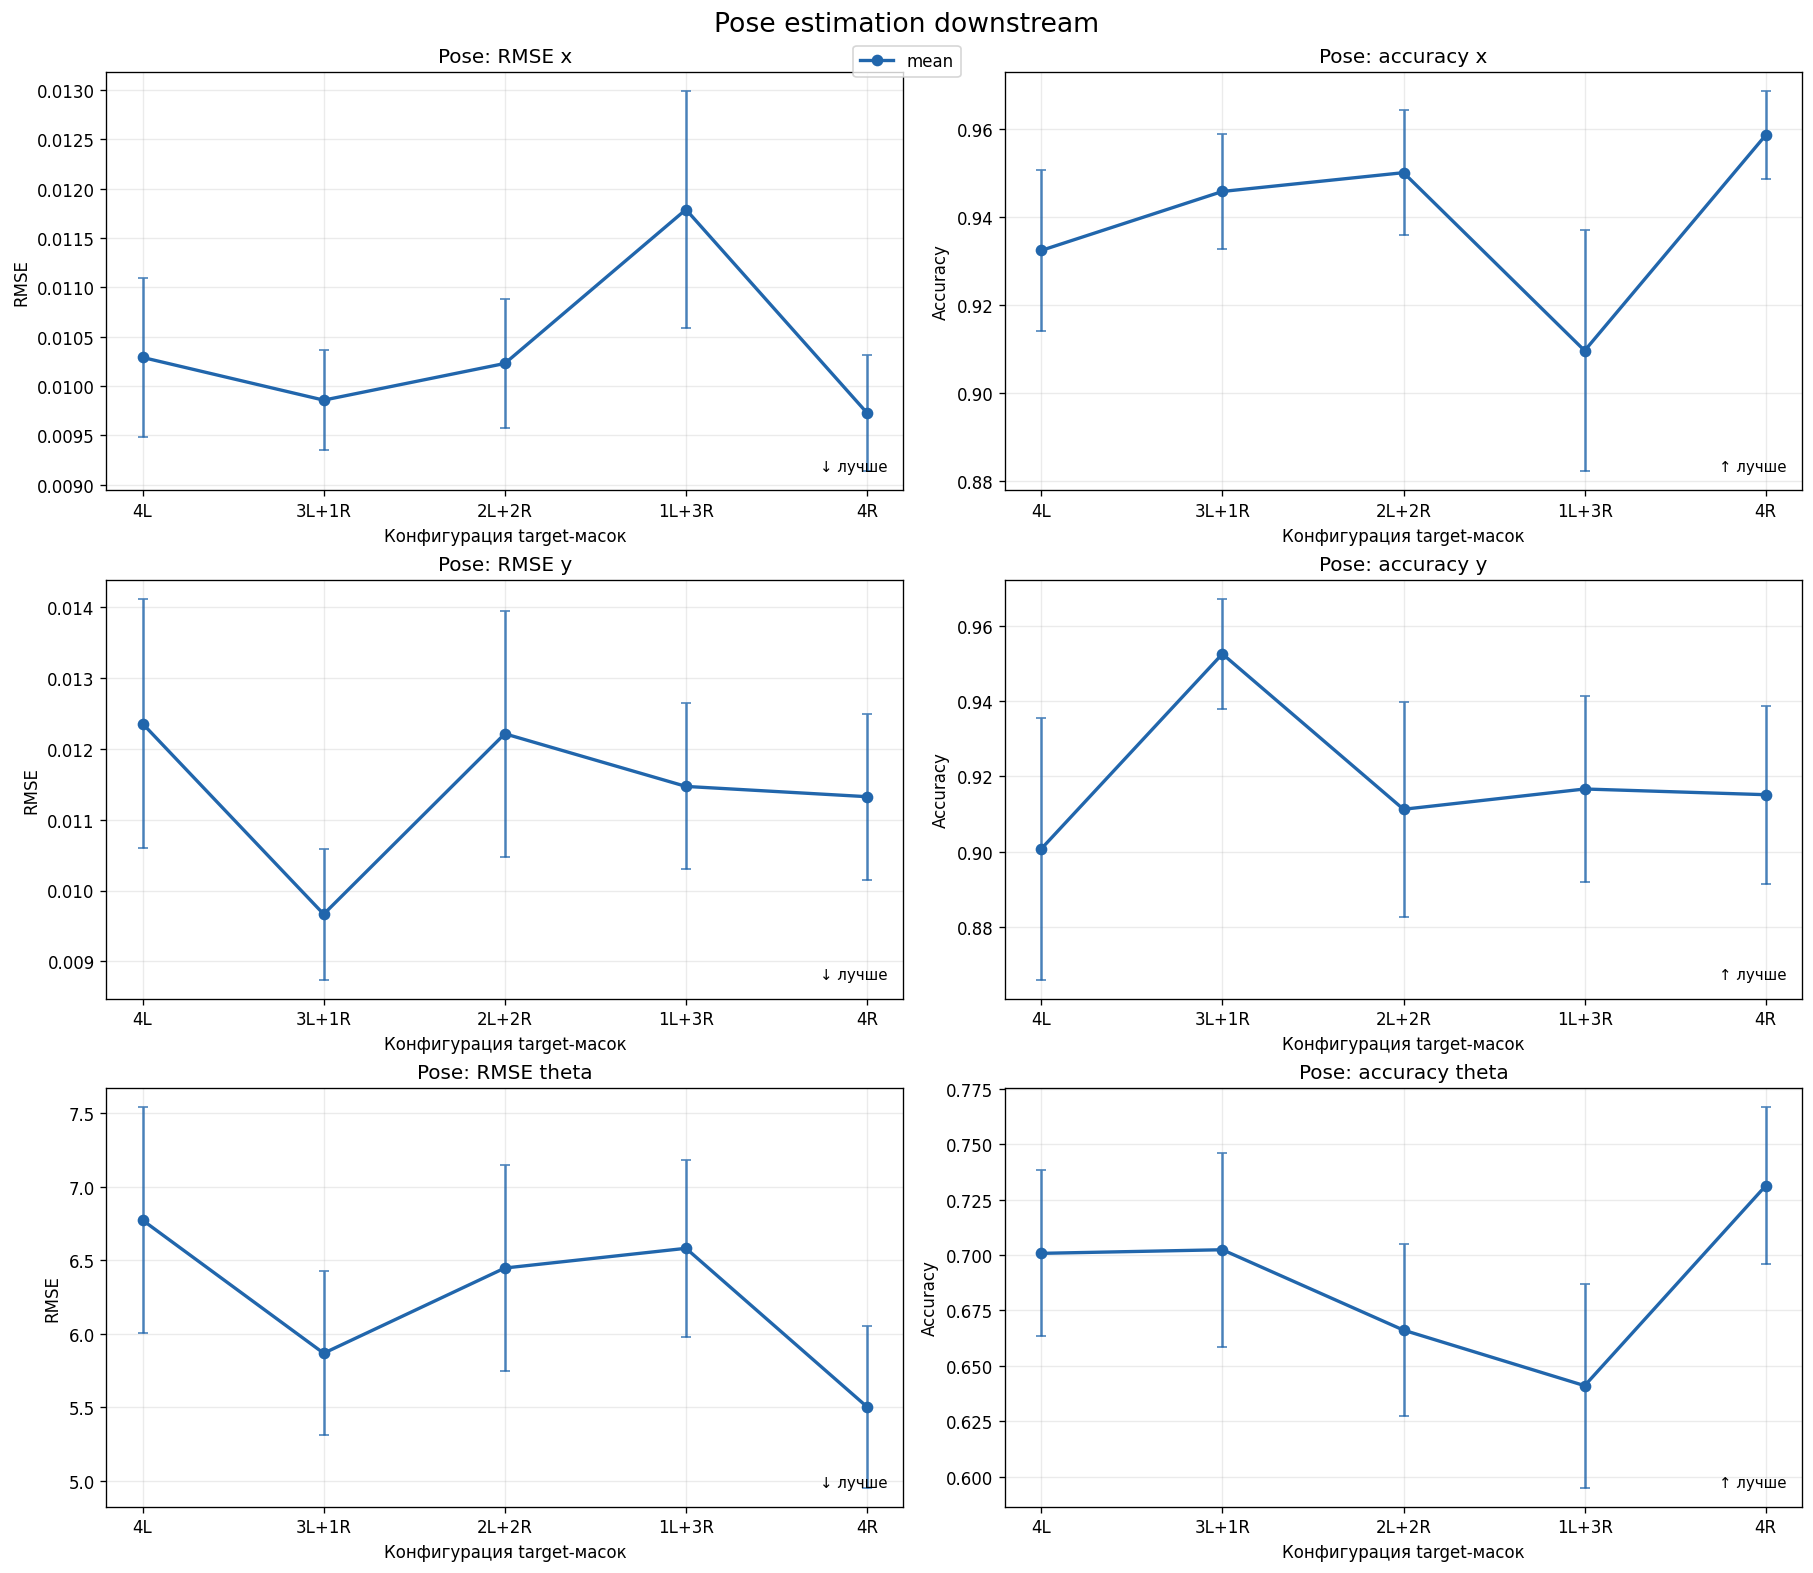

In [8]:
# 2. Pose estimation: для каждой координаты показываем RMSE и accuracy.
fig, axes = plt.subplots(3, 2, figsize=(15, 13), constrained_layout=True)
for i, coord in enumerate(['x', 'y', 'theta']):
    draw(axes[i, 0], 'pose', f'rmse_{coord}', f'Pose: RMSE {coord}', 'RMSE', lower_is_better=True)
    draw(axes[i, 1], 'pose', f'acc_{coord}', f'Pose: accuracy {coord}', 'Accuracy', lower_is_better=False)
fig.suptitle('Pose estimation downstream', fontsize=16)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 0.98))
plt.show()

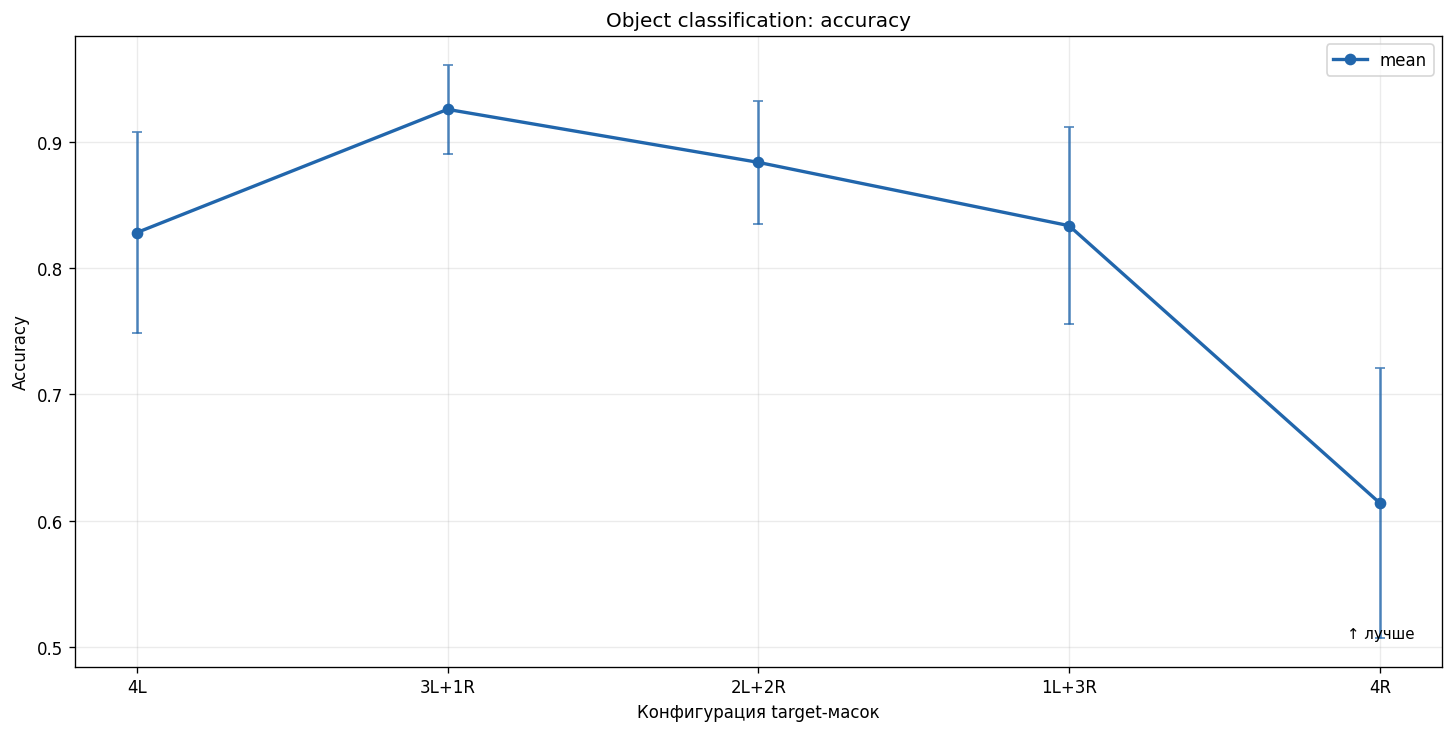

In [9]:
# 3. Object classification.
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
draw(ax, 'object_classification', 'acc', 'Object classification: accuracy', 'Accuracy', lower_is_better=False)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, ncol=5)
plt.show()

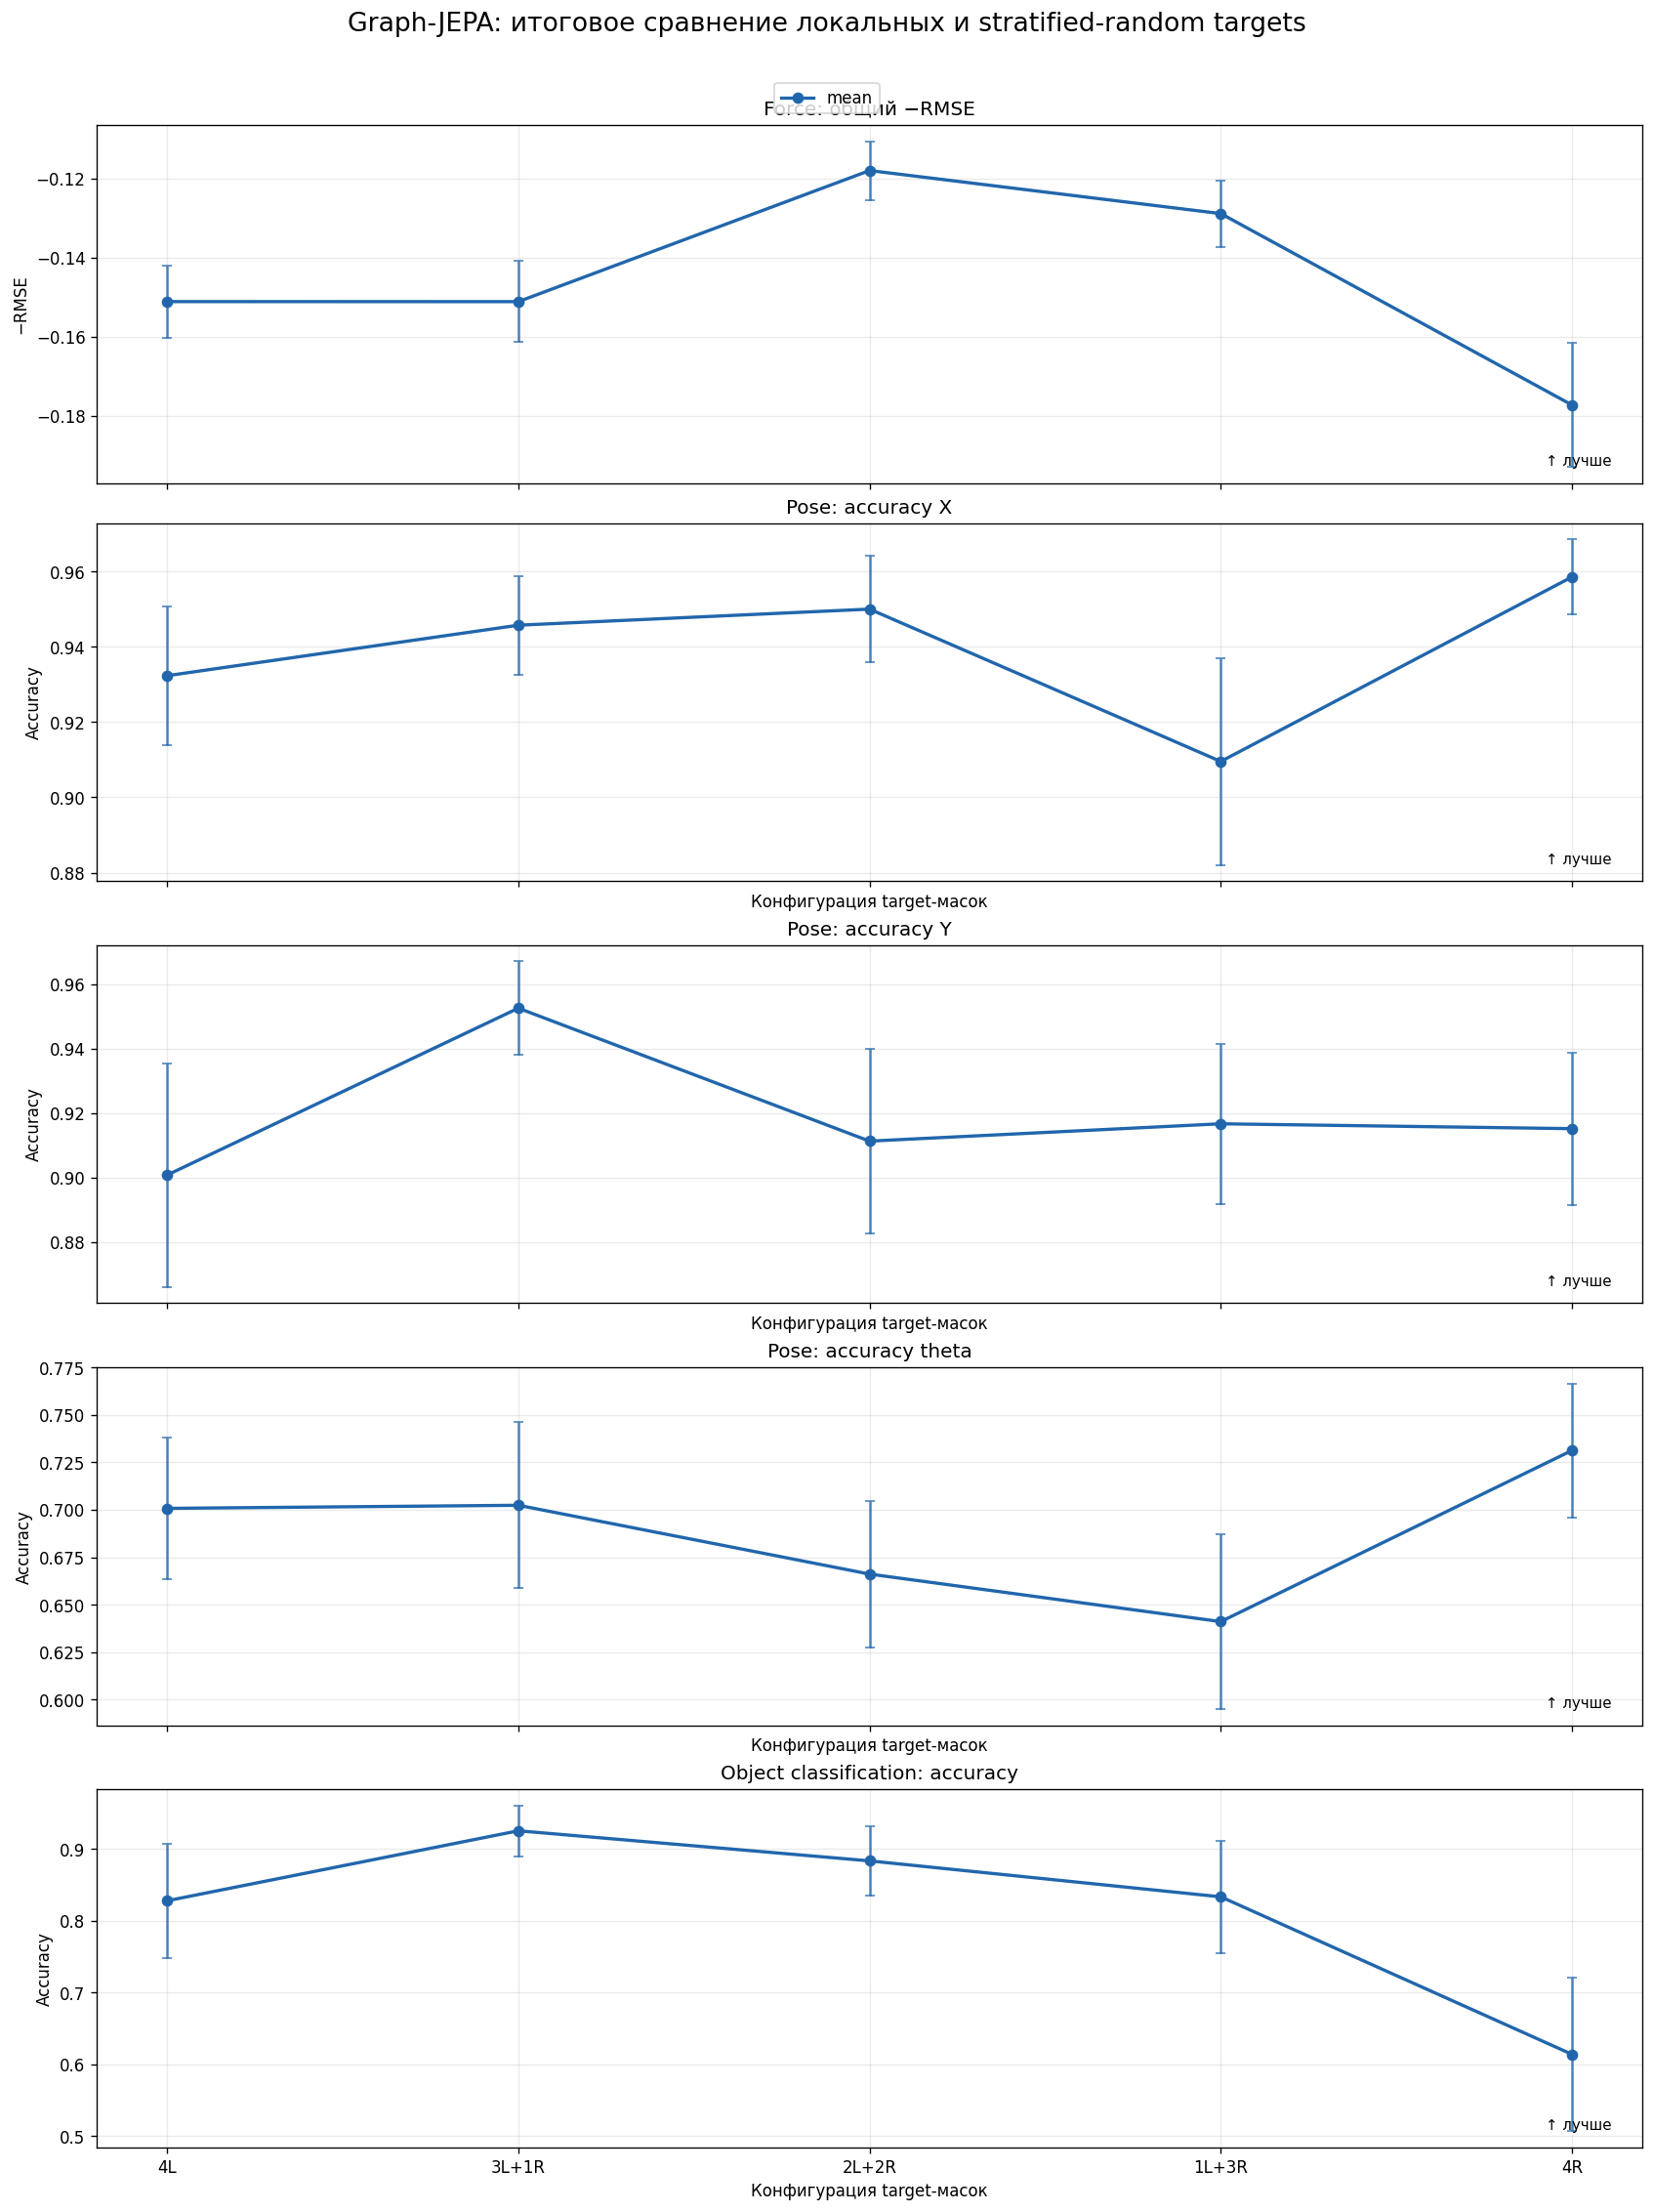

In [10]:
# Финальный компактный набор метрик: одна строка на ключевую задачу.
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True, constrained_layout=True)
part = series('force', 'rmse').sort_values('random_targets')
x = part['random_targets'].to_numpy()
y = -part['estimate'].to_numpy()
se = part['bootstrap_se'].to_numpy()
axes[0].plot(x, y, marker='o', linewidth=2, color='#2166ac', label='mean')
axes[0].errorbar(x, y, yerr=se, fmt='none', ecolor='#2166ac', capsize=3, alpha=0.8)
axes[0].set_title('Force: общий −RMSE')
axes[0].set_ylabel('−RMSE')
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(['4L', '3L+1R', '2L+2R', '1L+3R', '4R'])
axes[0].text(0.98, 0.04, '↑ лучше', transform=axes[0].transAxes, ha='right', va='bottom', fontsize=9)
draw(axes[1], 'pose', 'acc_x', 'Pose: accuracy X', 'Accuracy', lower_is_better=False)
draw(axes[2], 'pose', 'acc_y', 'Pose: accuracy Y', 'Accuracy', lower_is_better=False)
draw(axes[3], 'pose', 'acc_theta', 'Pose: accuracy theta', 'Accuracy', lower_is_better=False)
draw(axes[4], 'object_classification', 'acc', 'Object classification: accuracy', 'Accuracy', lower_is_better=False)
axes[-1].set_xlabel('Конфигурация target-масок')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 1.01))
fig.suptitle('Graph-JEPA: итоговое сравнение локальных и stratified-random targets', fontsize=16, y=1.04)
plt.show()
